## Diamont Dataset

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

In [56]:
df= pd.read_csv(r"diamonds.csv")

In [57]:
df.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


In [59]:
df.shape

(53940, 10)

In [60]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [61]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


### Problem Statement

The goal is to predict the price of a diamond (regression problem) based on its physical and quality attributes.

### Data Cleaning

In [62]:
## x,y,z should not be zero as they are the dimensions of the diamond. So droping them

In [63]:
(df[["x","y","z"]] == 0).sum()

x     8
y     7
z    20
dtype: int64

In [64]:
df = df[(df["x"] > 0) & (df["y"] > 0) & (df["z"] > 0)]

In [65]:
df.shape

(53920, 10)

In [66]:
df[df.duplicated()]

,carat,cut,color,clarity,depth,table,price,x,y,z
1005,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1006,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1007,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1008,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
2025,1.52,Good,E,I1,57.3,58.0,3105,7.53,7.42,4.28
...,...,...,...,...,...,...,...,...,...,...
47296,0.30,Good,J,VS1,63.4,57.0,394,4.23,4.26,2.69
47969,0.52,Ideal,D,VS2,61.8,55.0,1919,5.19,5.16,3.20
49326,0.51,Ideal,F,VVS2,61.2,56.0,2093,5.17,5.19,3.17
50079,0.51,Ideal,F,VVS2,61.2,56.0,2203,5.19,5.17,3.17


In [67]:
df = df.drop_duplicates()

In [68]:
df.shape

(53775, 10)

In [69]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [70]:
## cut,color,clarity are ordinal categorical, and other columns are continuous numerical

### Visualization

<Axes: xlabel='price', ylabel='Count'>

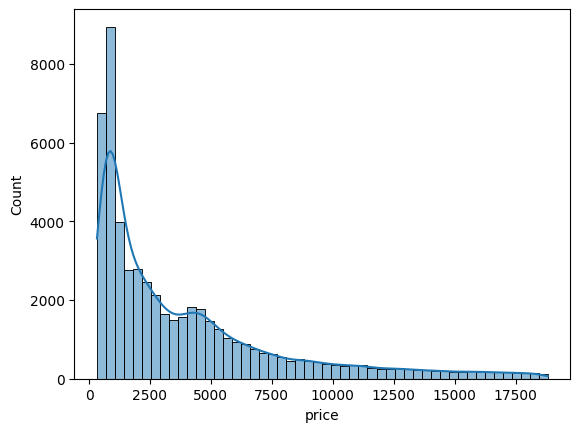

In [71]:
sns.histplot(df["price"],bins=50,kde=True)

<Axes: xlabel='carat', ylabel='Count'>

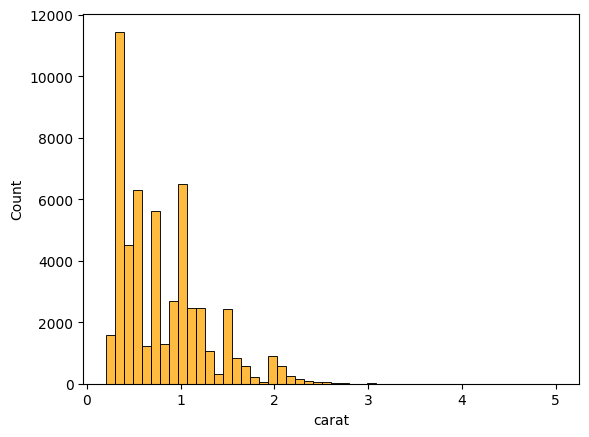

In [72]:
sns.histplot(df["carat"],bins=50,color="orange")

In [73]:
df.select_dtypes(include="str")

,cut,color,clarity
0,Ideal,E,SI2
1,Premium,E,SI1
2,Good,E,VS1
3,Premium,I,VS2
4,Good,J,SI2
...,...,...,...
53935,Ideal,D,SI1
53936,Good,D,SI1
53937,Very Good,D,SI1
53938,Premium,H,SI2


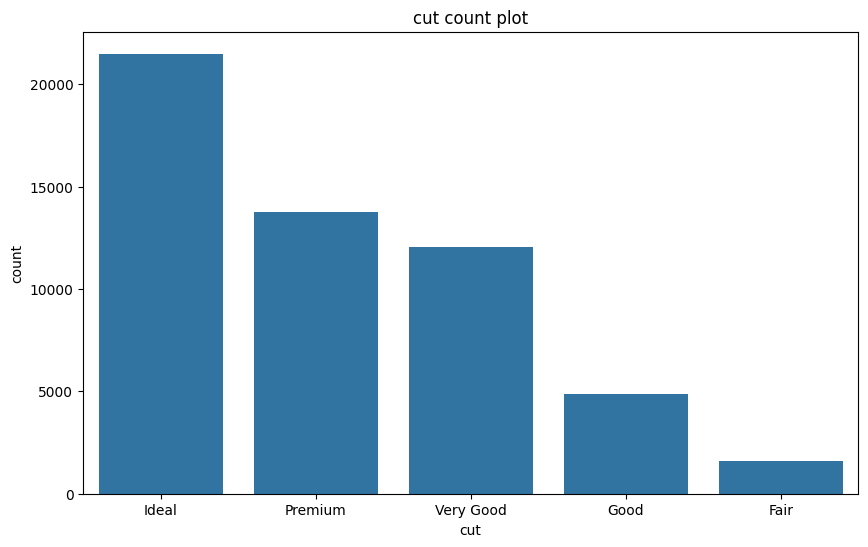

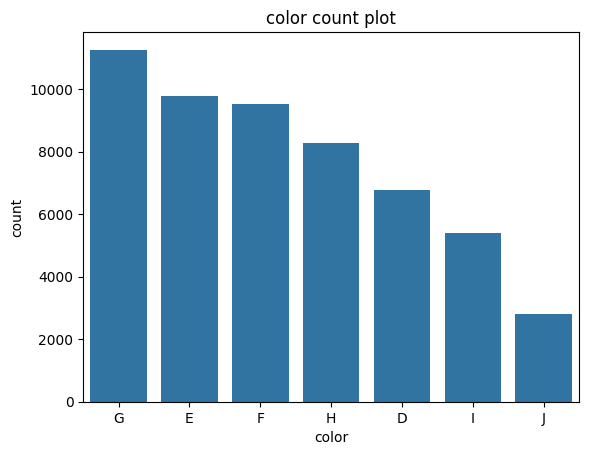

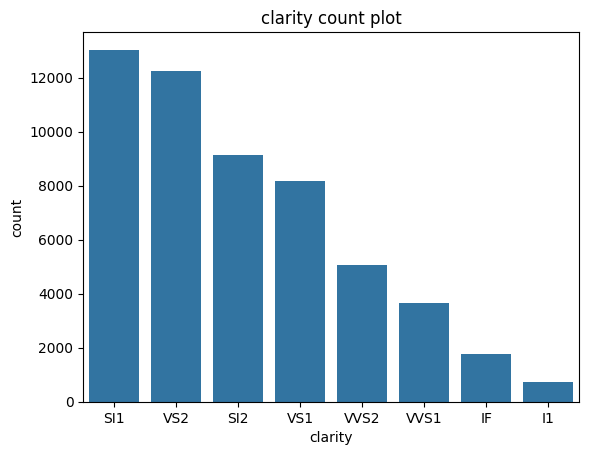

In [74]:
plt.figure(figsize=(10,6))
for col in ["cut","color","clarity"]:
    sns.countplot(data=df,x=col,order=df[col].value_counts().index)
    plt.title(f"{col} count plot")
    plt.show()

<Axes: >

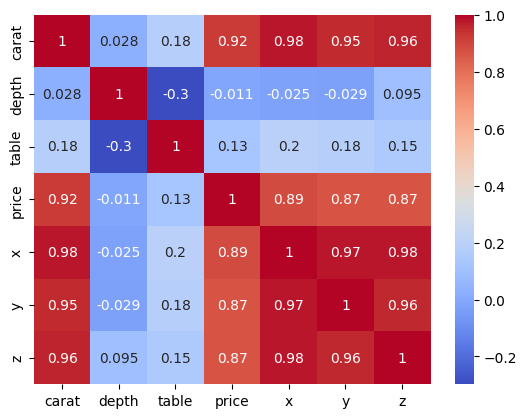

In [75]:
sns.heatmap(df.select_dtypes(include="number").corr(),annot=True,cmap="coolwarm")

In [76]:
## Carat is highly corelated with the size and price of the diamond

<Axes: xlabel='carat', ylabel='price'>

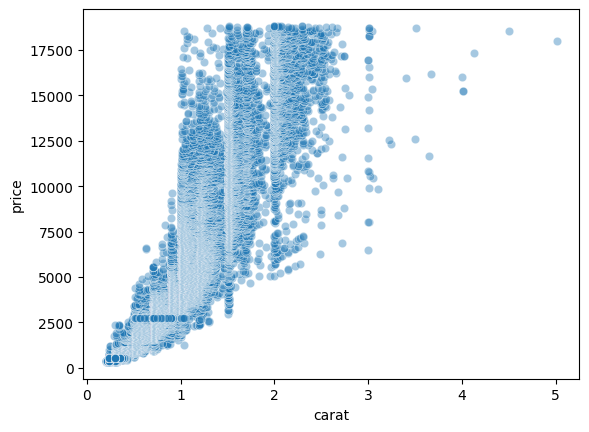

In [77]:
sns.scatterplot(y=df["price"],x=df["carat"],alpha = 0.4)

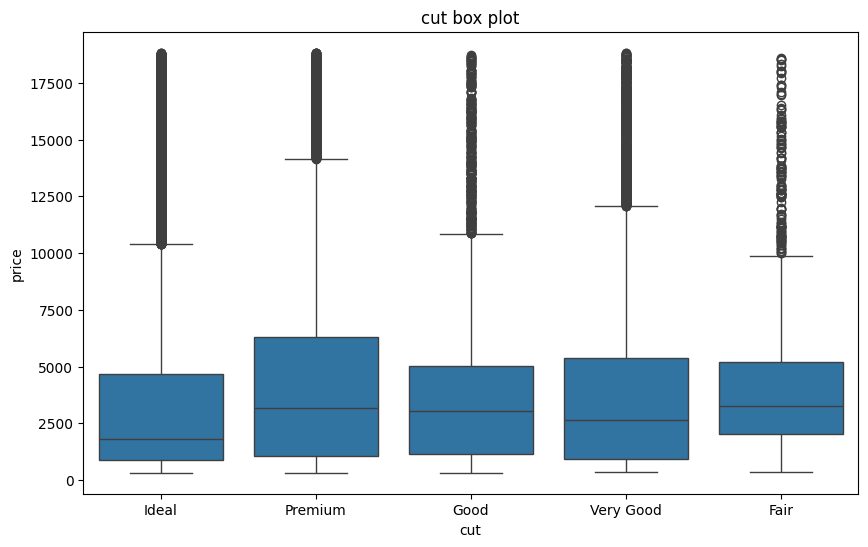

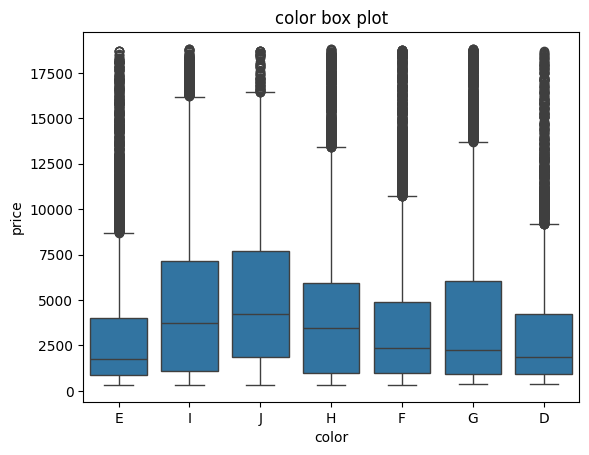

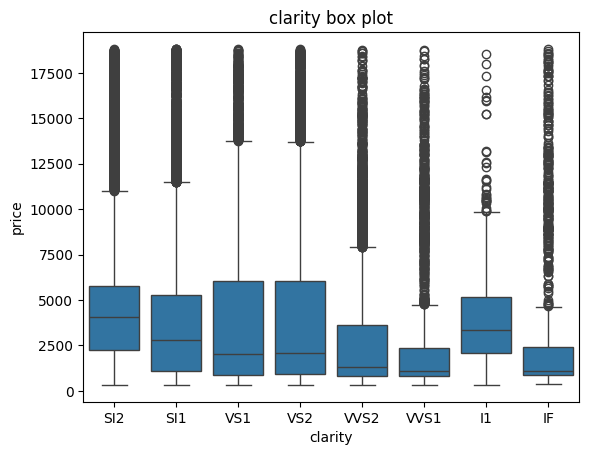

In [78]:
plt.figure(figsize=(10,6))
for col in ["cut","color","clarity"]:
    sns.boxplot(data=df,x=col,y="price")
    plt.title(f"{col} box plot")
    plt.show()

In [79]:
## With the median line we can see feature influence and due to the diamond's carat and size the prices are differing

### Pre-Processing

In [80]:
## Creating volume column to easier analysis

In [81]:
df["volume"] = (df["x"] * df["y"] * df["z"]).round(2)

In [82]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,volume
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,38.20
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,34.51
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,38.08
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,46.72
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,51.92


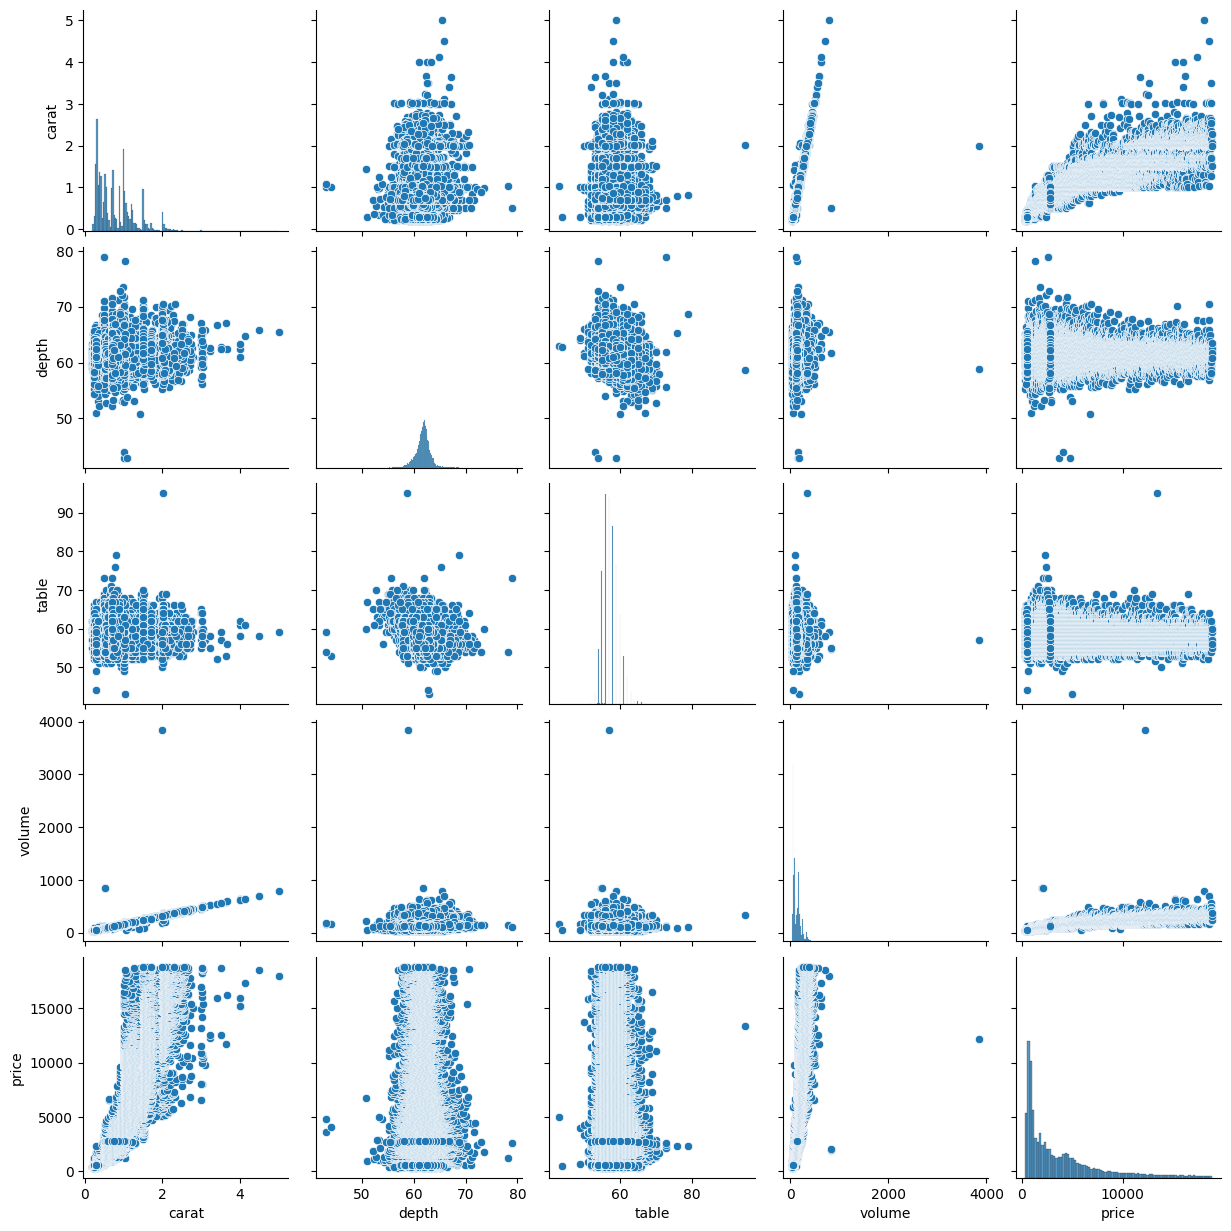

In [83]:
sns.pairplot(df,vars=["carat","depth","table","volume","price"])
plt.show()

In [84]:
## Encoding the categorical columns

In [85]:
od = OrdinalEncoder()
ordinal_columns = ["cut","color","clarity"]

In [86]:
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
color_order = ["J","I","H","G","F","E","D"]
clarity_order = ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']

In [87]:
ct = ColumnTransformer(transformers=[("ord",OrdinalEncoder(categories=[cut_order,color_order,clarity_order]),
                                      ["cut","color","clarity"])], ## Takes with array of the order of the categories
                       remainder="passthrough",
                       verbose_feature_names_out=False)

df_1 = ct.fit_transform(df)
cols = ct.get_feature_names_out()
df_bk = df.copy()
df = pd.DataFrame(df_1,columns=cols)

In [88]:
df_bk.head(7)

,carat,cut,color,clarity,depth,table,price,x,y,z,volume
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,38.20
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,34.51
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,38.08
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,46.72
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,51.92
5,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48,38.69
6,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47,38.83


In [89]:
df.head(7)

,cut,color,clarity,carat,depth,table,price,x,y,z,volume
0,4.0,5.0,1.0,0.23,61.5,55.0,326.0,3.95,3.98,2.43,38.20
1,3.0,5.0,2.0,0.21,59.8,61.0,326.0,3.89,3.84,2.31,34.51
2,1.0,5.0,4.0,0.23,56.9,65.0,327.0,4.05,4.07,2.31,38.08
3,3.0,1.0,3.0,0.29,62.4,58.0,334.0,4.20,4.23,2.63,46.72
4,1.0,0.0,1.0,0.31,63.3,58.0,335.0,4.34,4.35,2.75,51.92
5,2.0,0.0,5.0,0.24,62.8,57.0,336.0,3.94,3.96,2.48,38.69
6,2.0,1.0,6.0,0.24,62.3,57.0,336.0,3.95,3.98,2.47,38.83


### Normalization of the data

In [90]:
## Since Carat and price are right skewed we will apply log transformation to them

In [91]:
df["log_price"] = np.log1p(df["price"])
df["log_carat"] = np.log1p(df["carat"])

<Axes: xlabel='log_price', ylabel='Count'>

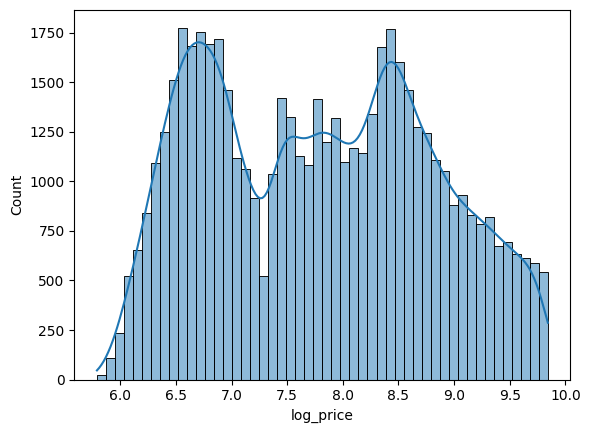

In [92]:
sns.histplot(df["log_price"],bins=50,kde=True)

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,root_mean_squared_error

### Slpit data

In [94]:
X = df.drop(columns=["price","log_price"])
y = df["log_price"]

In [95]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=42)

In [96]:
sc = StandardScaler()

In [97]:
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### Model Building

In [98]:
lr_model = LinearRegression()

In [99]:
lr_model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Prediction and evaluation

In [100]:
y_pred_test = lr_model.predict(X_test)
y_pred_train = lr_model.predict(X_train)

In [101]:
## Evalution

In [102]:
### For test data

In [103]:
print("Mean Squared Error test:", mean_squared_error(y_test, y_pred_test))
print("Root Mean Squared Error test:", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("Mean Absolute Error test:", mean_absolute_error(y_test, y_pred_test))
print("R-squared test:", r2_score(y_test, y_pred_test))

Mean Squared Error test: 0.020182047764544592
Root Mean Squared Error test: 0.1420635342533213
Mean Absolute Error test: 0.10906365824934061
R-squared test: 0.9801873071456186


In [104]:
## Train data
print("Mean Squared Error train:", mean_squared_error(y_train, y_pred_train))
print("Root Mean Squared Error train:", root_mean_squared_error(y_train, y_pred_train))
print("Mean Absolute Error train:", mean_absolute_error(y_train, y_pred_train))
print("R-squared train:", r2_score(y_train, y_pred_train))

Mean Squared Error train: 0.019227090320131073
Root Mean Squared Error train: 0.138661783920917
Mean Absolute Error train: 0.10759644063004001
R-squared train: 0.9813328918671306


In [105]:
## R2 score is 0.98 which is good for linear regression model. It means that the model can explain 98% of the variance in the target variable.

<Axes: xlabel='log_price', ylabel='Count'>

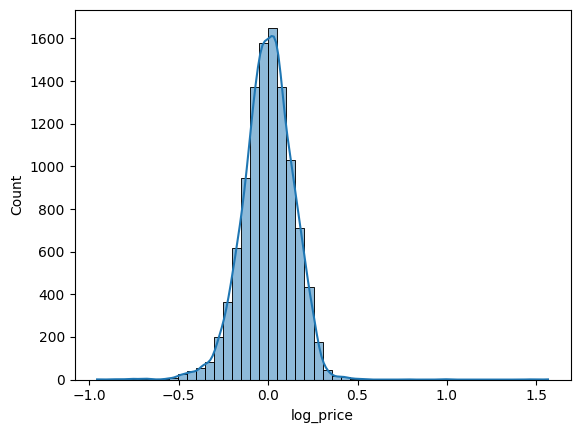

In [106]:
residuals = y_test - y_pred_test
sns.histplot(residuals, bins=50, kde=True)


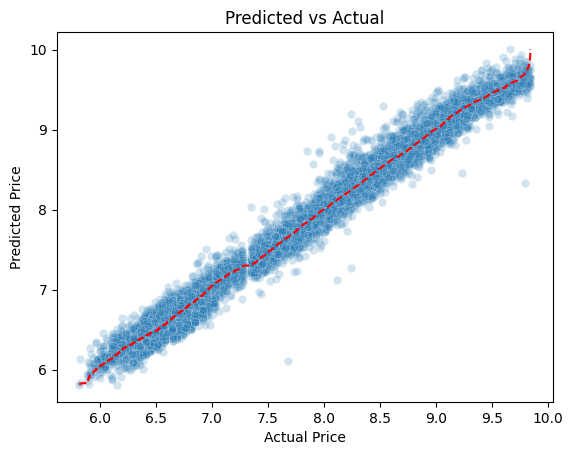

In [107]:
# Predicted vs Actual
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.2)
plt.plot(y_test.sort_values(),pd.Series(y_pred_test).sort_values(),'r--')
#plt.plot([5,11], [5,11], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual')
plt.show()

In [108]:
## Real time predictions

In [109]:
df.sample()

,cut,color,clarity,carat,depth,table,price,x,y,z,volume,log_price,log_carat
42616,4.0,1.0,5.0,0.54,61.7,54.0,1346.0,5.25,5.29,3.25,90.26,7.205635,0.431782


In [110]:
data = {
    "cut":4.0,
    "color": 0.0,
    "clarity": 4.0,
    "carat": 0.32,
    "depth": 61.3,
    "table": 57,
    "x":4.43,
    "y":4.41,
    "z":2.47,
    "volume": 52.94,
    "log_carat": 0.277632,
}

In [111]:
data_df = pd.DataFrame([data])
data_df

,cut,color,clarity,carat,depth,table,x,y,z,volume,log_carat
0,4.0,0.0,4.0,0.32,61.3,57,4.43,4.41,2.47,52.94,0.277632


In [112]:
data = sc.transform(data_df)

In [113]:
lr_model.predict(data)[0] ## The predicted log price of the diamond is 6.286. Its matching to the y actual.

np.float64(6.28699705424277)

In [114]:
## Saving the model

In [115]:
import joblib

In [116]:
lr_model.sc = sc
lr_model.ct = ct
joblib.dump(lr_model,"lr_diamond_model.pkl")

['lr_diamond_model.pkl']